<a href="https://colab.research.google.com/github/Oscardobanks/machine_learning_practice/blob/main/Non_Vectorised_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
# Google sheet.

google_sheet_id = '1ziWF38RKYvs4ysqwcuPRzC7N1WiX3hk7'

url = f'https://docs.google.com/uc?id={google_sheet_id}&export=download'

try:

    df = pd.read_csv(url)

    print("Google Sheet data loaded successfully:")

    display(df.head())

except Exception as e:

    print(f"Error loading Google Sheet: {e}")

Google Sheet data loaded successfully:


,x1,x2,x3,label
0,-0.332727,-0.696181,-0.286767,0
1,-1.510220,-1.375861,-1.197257,0
2,-1.256076,-1.228764,-1.785996,0
3,-0.772276,-0.409598,-0.267973,0
4,-1.346263,0.112805,0.612268,0


In [15]:
X1 = np.array(df['x1'])
X2 = np.array(df['x2'])
X3 = np.array(df['x3'])

X = np.column_stack((X1, X2, X3))

Y = np.array(df['label'])

display(X.shape, Y.shape)
X, Y

(200, 3)

(200,)

(array([[-3.32727288e-01, -6.96181041e-01, -2.86766581e-01],
        [-1.51022049e+00, -1.37586113e+00, -1.19725687e+00],
        [-1.25607624e+00, -1.22876370e+00, -1.78599642e+00],
        [-7.72276364e-01, -4.09598435e-01, -2.67973078e-01],
        [-1.34626309e+00,  1.12805059e-01,  6.12267555e-01],
        [ 2.15636892e-01,  2.98918001e-01,  1.03272447e+00],
        [ 6.70567936e-01,  1.92308238e-01,  1.64721375e+00],
        [-1.31646482e-01,  6.91599305e-01,  1.59772213e-02],
        [ 2.38841369e-01,  9.04251521e-01,  2.91584612e-01],
        [-6.28618178e-01, -3.27819886e-01, -3.79269256e-02],
        [ 1.20913644e+00,  7.92472643e-01, -4.47009021e-01],
        [ 9.40205968e-01,  1.49413905e+00,  3.53375636e-01],
        [-1.23353761e+00,  6.66406329e-03,  7.03680945e-01],
        [ 1.34774888e-01, -1.51270519e-01, -5.32092286e-01],
        [-3.77867697e-01,  5.61597099e-01,  1.07528066e-01],
        [ 7.44568943e-01,  2.67232902e-01,  9.54881922e-01],
        [-8.67011677e-01

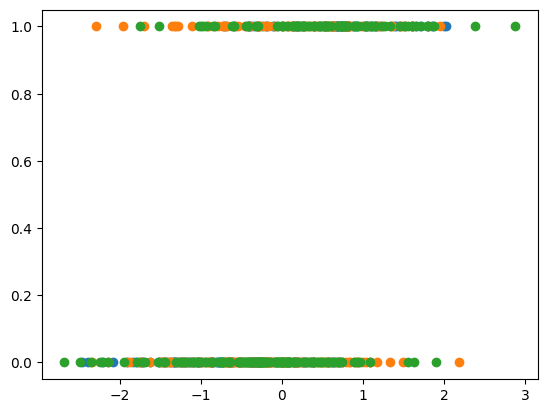

In [18]:
# Plot the values X and Y
plt.plot(X, Y, 'o')
plt.show()

In [23]:
# Define logistic function
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

In [39]:
# Initialize training parameters and hyperparameters
m0, m1, m2, m3 = 0.3, 0.3, 0.3, 0.3
alpha = 0.01
epochs = 100_000
costs = []

In [40]:
# Visualization of predictions, cost and gradient for each data point.
z = m0 + m1 * X1 + m2 * X2 + m3 * X3
Y_pred = sigmoid(z)
cost = -(Y * np.log(Y_pred) + (1 - Y) * np.log(1 - Y_pred))
raw_residual = Y_pred - Y

# Gradients for each parameter
dm0 = raw_residual
dm1 = raw_residual * X1
dm2 = raw_residual * X2
dm3 = raw_residual * X3

# Make Y_pred, Y, cost into a pandas dataframe. This allows us to
# have an intuitive view of the impact of the NLL cost function.
df = pd.DataFrame({
    'Y_pred': Y_pred, 'Y': Y, 'cost': cost,
    'dm0': dm0, 'dm1': dm1, 'dm2': dm2, 'dm3': dm3,
})
print('dm0:', np.mean(dm0), '\ndm1:', np.mean(dm1), '\ndm2:', np.mean(dm2), '\ndm3:', np.mean(dm3))
df.head(10)

dm0: 0.15172003318205327 
dm1: -0.17470534895723241 
dm2: 0.004696268123321558 
dm3: -0.07602211748714877


,Y_pred,Y,cost,dm0,dm1,dm2,dm3
0,0.476342,0,0.646917,0.476342,-0.158492,-0.331620,-0.136599
1,0.283940,0,0.333991,0.283940,-0.428812,-0.390662,-0.339949
2,0.272644,0,0.318339,0.272644,-0.342461,-0.335015,-0.486941
3,0.466313,0,0.627945,0.466313,-0.360122,-0.191001,-0.124959
4,0.528380,0,0.751582,0.528380,-0.711339,0.059604,0.323510
5,0.682261,1,0.382342,-0.317739,-0.068516,-0.094978,-0.328136
6,0.741356,1,0.299275,-0.258644,-0.173439,-0.049739,-0.426042
7,0.616041,0,0.957220,0.616041,-0.081100,0.426054,0.009843
8,0.674894,0,1.123603,0.674894,0.161193,0.610274,0.196789
9,0.500423,0,0.693993,0.500423,-0.314575,-0.164048,-0.018979


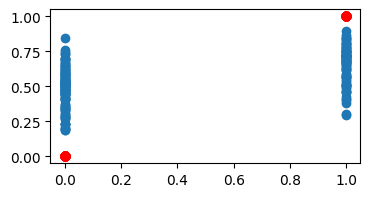

In [41]:
# Plot Y vs. Y_pred before training, using the initial parameter values
plt.figure(figsize=(4, 2))
plt.scatter(Y, Y_pred)
plt.scatter(Y, Y, color='red')
plt.show()

cost: 0.0627459577083609 
dm0: 0.0002959408203676189 
dm1: -0.002554645124915754 
dm2: 0.0018432078366343062 
dm3: -0.001192173004792565


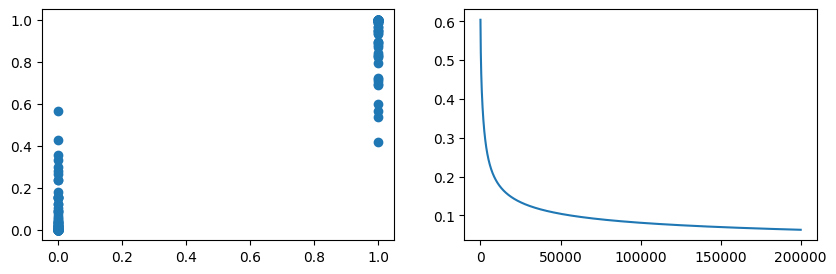

In [43]:
for i in range(epochs):
    # Predictions, cost and gradient for each data point.
    z = m0 + m1 * X1 + m2 * X2 + m3 * X3
    Y_pred = sigmoid(z)
    cost = -np.mean(Y * np.log(Y_pred) + (1 - Y) * np.log(1 - Y_pred))
    costs.append(cost)

    # Gradients for each parameter
    raw_residual = Y_pred - Y
    dm0 = np.mean(raw_residual)
    dm1 = np.mean(raw_residual * X1)
    dm2 = np.mean(raw_residual * X2)
    dm3 = np.mean(raw_residual * X3)

    # Parameter updates.
    m0 = m0 - alpha * dm0
    m1 = m1 - alpha * dm1
    m2 = m2 - alpha * dm2
    m3 = m3 - alpha * dm3

# Print gradients.
print('cost:', cost, '\ndm0:', dm0, '\ndm1:', dm1, '\ndm2:', dm2, '\ndm3:', dm3)
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(Y, Y_pred, 'o')

plt.subplot(1, 2, 2)
plt.plot(costs)